# Smart Winter Planner - Exploratory Data Analysis
## Pittsburgh Winter Weather Data (2015-2025)

**Objective:** Understand the characteristics, distributions, and patterns in 10 years of Pittsburgh winter weather data to inform feature engineering and model development.

**Dataset:** NOAA Pittsburgh International Airport (USW00094823)  
**Time Period:** December 2014 - February 2025  
**Focus:** Winter months (December, January, February)

In [21]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Initial Inspection

In [22]:
# Load data
df = pd.read_csv('../data/raw/pittsburgh_winters_10years.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (3712, 12)

Columns: ['STATION', 'NAME', 'DATE', 'AWND', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'WSF5']

First few rows:


,STATION,NAME,DATE,AWND,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WSF2,WSF5
0,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-01,12.75,0.00,0.0,0.0,25,35,20,25.1,35.1
1,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-02,6.26,0.00,0.0,0.0,31,37,24,14.1,19.0
2,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-03,7.16,0.56,0.0,0.0,32,58,24,15.0,21.9
3,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-04,16.33,0.06,0.0,0.0,53,61,32,29.1,38.9
4,USW00094823,"PITTSBURGH INTERNATIONAL AIRPORT, PA US",2015-01-05,14.76,0.01,0.4,0.0,24,32,14,30.0,36.0


In [23]:
# Basic info
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3712 entries, 0 to 3711
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  3712 non-null   object 
 1   NAME     3712 non-null   object 
 2   DATE     3712 non-null   object 
 3   AWND     3710 non-null   float64
 4   PRCP     3712 non-null   float64
 5   SNOW     3712 non-null   float64
 6   SNWD     3712 non-null   float64
 7   TAVG     3712 non-null   int64  
 8   TMAX     3712 non-null   int64  
 9   TMIN     3712 non-null   int64  
 10  WSF2     3710 non-null   float64
 11  WSF5     3694 non-null   float64
dtypes: float64(6), int64(3), object(3)
memory usage: 348.1+ KB


In [24]:
# Convert DATE to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Add month and year for analysis
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df['MONTH_NAME'] = df['DATE'].dt.month_name()

print("Date range:")
print(f"  Start: {df['DATE'].min()}")
print(f"  End: {df['DATE'].max()}")
print(f"  Duration: {(df['DATE'].max() - df['DATE'].min()).days} days")

Date range:
  Start: 2015-01-01 00:00:00
  End: 2025-02-28 00:00:00
  Duration: 3711 days


## 2. Missing Values Analysis

Missing Values Summary:
      Missing Count  Percentage
WSF5             18       0.485
AWND              2       0.054
WSF2              2       0.054


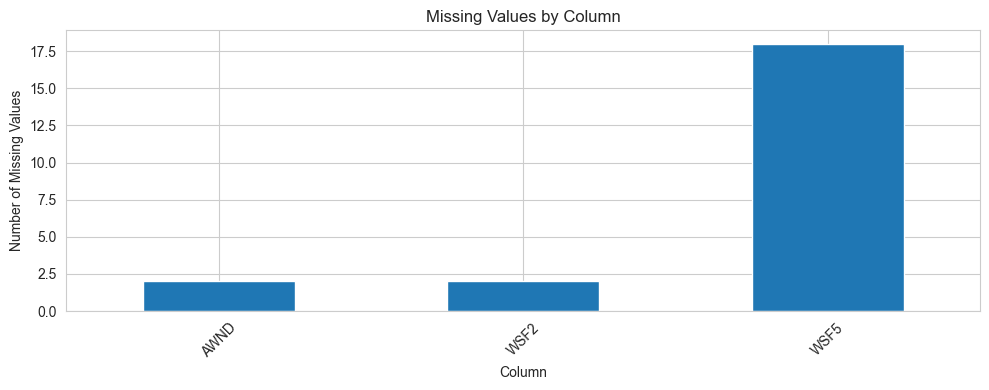

In [25]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
if missing.sum() > 0:
    plt.figure(figsize=(10, 4))
    missing[missing > 0].plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.xlabel('Column')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values!")

## 3. Descriptive Statistics

In [26]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# Descriptive statistics
print("\nDescriptive Statistics:")
df[numeric_cols].describe()

Numeric columns: ['AWND', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'WSF5', 'YEAR', 'MONTH']

Descriptive Statistics:


,AWND,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WSF2,WSF5,YEAR,MONTH
count,3710.000,3712.000,3712.000,3712.000,3712.000,3712.000,3712.000,3710.000,3694.000,3712.000,3712.000
mean,7.180,0.116,0.105,0.284,53.076,62.307,43.799,18.096,24.172,2019.588,6.442
std,3.333,0.279,0.515,1.070,17.937,19.247,17.462,6.356,8.508,2.932,3.480
min,0.220,0.000,0.000,0.000,-1.000,6.000,-10.000,4.900,6.900,2015.000,1.000
25%,4.700,0.000,0.000,0.000,38.000,47.000,30.000,14.100,18.100,2017.000,3.000
50%,6.710,0.000,0.000,0.000,55.000,65.000,45.000,17.000,23.000,2020.000,6.000
75%,9.170,0.090,0.000,0.000,69.000,79.000,59.000,21.900,29.100,2022.000,9.000
max,23.710,3.730,9.300,9.800,83.000,95.000,76.000,59.900,74.900,2025.000,12.000


In [27]:
# Focus on key weather variables
key_vars = ['TAVG', 'TMAX', 'TMIN', 'PRCP', 'SNOW', 'SNWD', 'AWND']
available_vars = [v for v in key_vars if v in df.columns]

print("\nKey Weather Variables Summary:")
summary = df[available_vars].describe().T
summary['range'] = summary['max'] - summary['min']
summary


Key Weather Variables Summary:


,count,mean,std,min,25%,50%,75%,max,range
TAVG,3712.0,53.076,17.937,-1.00,38.0,55.00,69.00,83.00,84.00
TMAX,3712.0,62.307,19.247,6.00,47.0,65.00,79.00,95.00,89.00
TMIN,3712.0,43.799,17.462,-10.00,30.0,45.00,59.00,76.00,86.00
PRCP,3712.0,0.116,0.279,0.00,0.0,0.00,0.09,3.73,3.73
SNOW,3712.0,0.105,0.515,0.00,0.0,0.00,0.00,9.30,9.30
SNWD,3712.0,0.284,1.070,0.00,0.0,0.00,0.00,9.80,9.80
AWND,3710.0,7.180,3.333,0.22,4.7,6.71,9.17,23.71,23.49


## 4. Target Variable Analysis: SNOW

**Most Important:** Understanding snowfall distribution is critical for model development.

In [28]:
# Snowfall statistics
print("SNOWFALL ANALYSIS")
print("="*70)

if 'SNOW' in df.columns:
    snow = df['SNOW'].fillna(0)
    
    print(f"\nTotal days: {len(snow)}")
    print(f"Days with snow (>0): {(snow > 0).sum()} ({(snow > 0).mean()*100:.1f}%)")
    print(f"Days with measurable snow (>0.1''): {(snow > 0.1).sum()} ({(snow > 0.1).mean()*100:.1f}%)")
    print(f"Days with significant snow (>1.0''): {(snow > 1.0).sum()} ({(snow > 1.0).mean()*100:.1f}%)")
    print(f"Days with heavy snow (>3.0''): {(snow > 3.0).sum()} ({(snow > 3.0).mean()*100:.1f}%)")
    
    print(f"\nSnowfall Statistics:")
    print(f"  Mean: {snow.mean():.3f} inches")
    print(f"  Median: {snow.median():.3f} inches")
    print(f"  Std Dev: {snow.std():.3f} inches")
    print(f"  Max: {snow.max():.3f} inches")
    
    # For non-zero days only
    snow_nonzero = snow[snow > 0]
    print(f"\nFor snow days only (>0):")
    print(f"  Mean: {snow_nonzero.mean():.3f} inches")
    print(f"  Median: {snow_nonzero.median():.3f} inches")
    print(f"  Std Dev: {snow_nonzero.std():.3f} inches")
else:
    print("SNOW column not found!")

SNOWFALL ANALYSIS

Total days: 3712
Days with snow (>0): 365 (9.8%)
Days with measurable snow (>0.1''): 308 (8.3%)
Days with significant snow (>1.0''): 123 (3.3%)
Days with heavy snow (>3.0''): 27 (0.7%)

Snowfall Statistics:
  Mean: 0.105 inches
  Median: 0.000 inches
  Std Dev: 0.515 inches
  Max: 9.300 inches

For snow days only (>0):
  Mean: 1.065 inches
  Median: 0.600 inches
  Std Dev: 1.294 inches


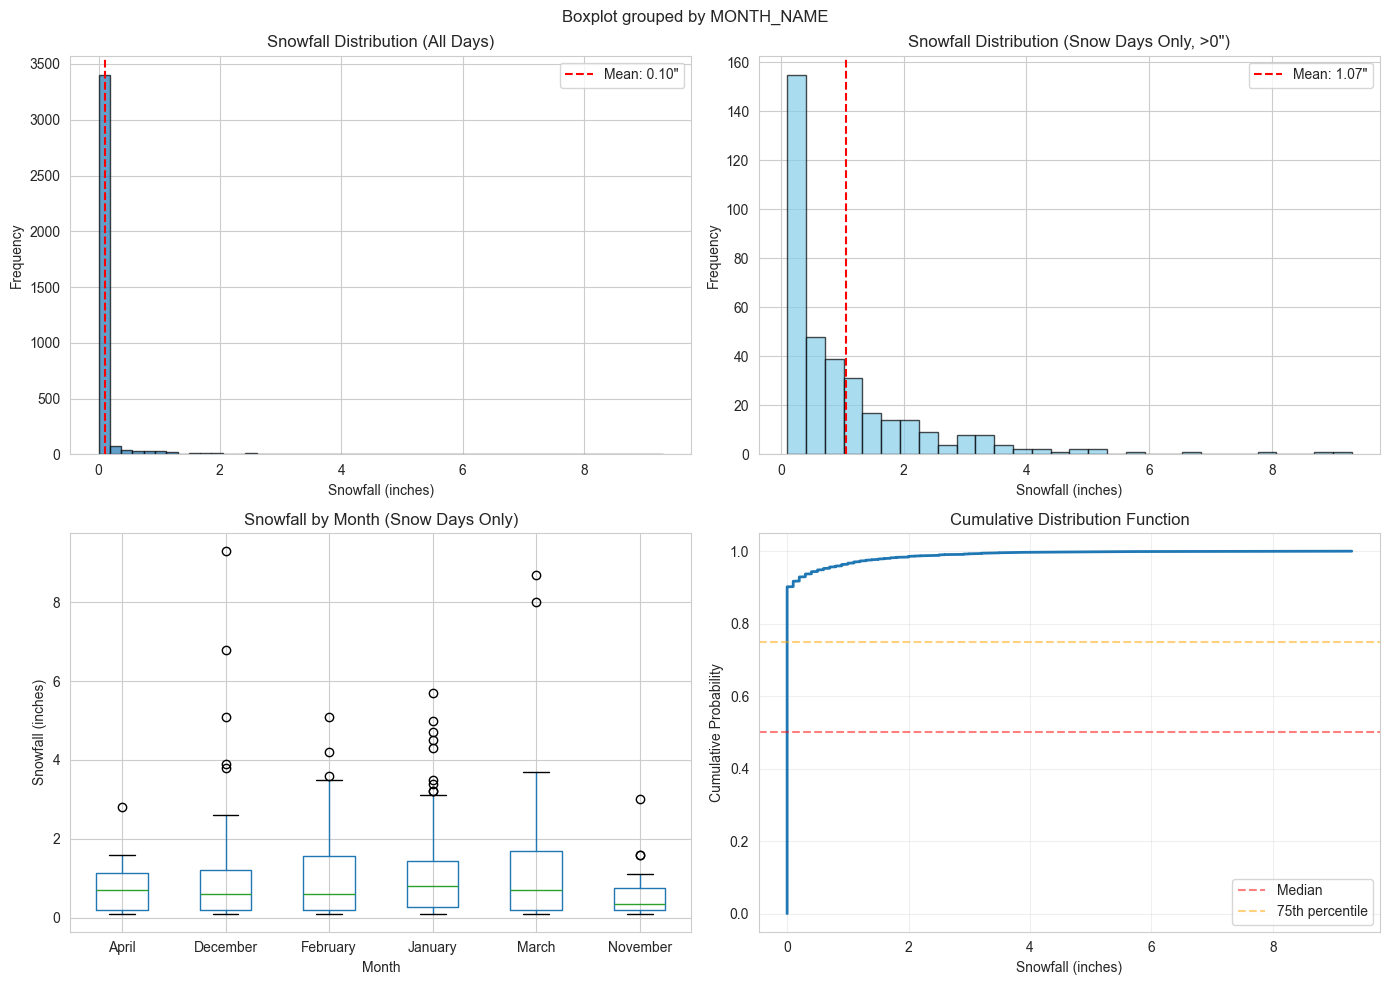


✓ KEY INSIGHT: Zero-inflated distribution!
  90.2% of days have NO snow
  This makes regression challenging - model must handle both:
    1. Binary classification (snow vs no snow)
    2. Continuous regression (how much snow)


In [29]:
# Visualize snowfall distribution
if 'SNOW' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Histogram (all days)
    axes[0, 0].hist(snow, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Snowfall (inches)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Snowfall Distribution (All Days)')
    axes[0, 0].axvline(snow.mean(), color='red', linestyle='--', label=f'Mean: {snow.mean():.2f}"')
    axes[0, 0].legend()
    
    # 2. Histogram (snow days only)
    axes[0, 1].hist(snow_nonzero, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 1].set_xlabel('Snowfall (inches)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Snowfall Distribution (Snow Days Only, >0")')
    axes[0, 1].axvline(snow_nonzero.mean(), color='red', linestyle='--', label=f'Mean: {snow_nonzero.mean():.2f}"')
    axes[0, 1].legend()
    
    # 3. Box plot by month
    df[df['SNOW'] > 0].boxplot(column='SNOW', by='MONTH_NAME', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Snowfall (inches)')
    axes[1, 0].set_title('Snowfall by Month (Snow Days Only)')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=0)
    
    # 4. Cumulative distribution
    sorted_snow = np.sort(snow)
    cumulative = np.arange(1, len(sorted_snow) + 1) / len(sorted_snow)
    axes[1, 1].plot(sorted_snow, cumulative, linewidth=2)
    axes[1, 1].set_xlabel('Snowfall (inches)')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].set_title('Cumulative Distribution Function')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Median')
    axes[1, 1].axhline(0.75, color='orange', linestyle='--', alpha=0.5, label='75th percentile')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ KEY INSIGHT: Zero-inflated distribution!")
    print(f"  {(snow == 0).mean()*100:.1f}% of days have NO snow")
    print("  This makes regression challenging - model must handle both:")
    print("    1. Binary classification (snow vs no snow)")
    print("    2. Continuous regression (how much snow)")

## 5. Temperature Analysis

In [30]:
# Temperature statistics
temp_vars = ['TAVG', 'TMAX', 'TMIN']
available_temps = [t for t in temp_vars if t in df.columns]

if available_temps:
    print("TEMPERATURE ANALYSIS")
    print("="*70)
    
    for temp in available_temps:
        print(f"\n{temp}:")
        print(f"  Mean: {df[temp].mean():.1f}°F")
        print(f"  Min: {df[temp].min():.1f}°F")
        print(f"  Max: {df[temp].max():.1f}°F")
        print(f"  Days below freezing (32°F): {(df[temp] < 32).sum()} ({(df[temp] < 32).mean()*100:.1f}%)")

TEMPERATURE ANALYSIS

TAVG:
  Mean: 53.1°F
  Min: -1.0°F
  Max: 83.0°F
  Days below freezing (32°F): 509 (13.7%)

TMAX:
  Mean: 62.3°F
  Min: 6.0°F
  Max: 95.0°F
  Days below freezing (32°F): 250 (6.7%)

TMIN:
  Mean: 43.8°F
  Min: -10.0°F
  Max: 76.0°F
  Days below freezing (32°F): 1012 (27.3%)


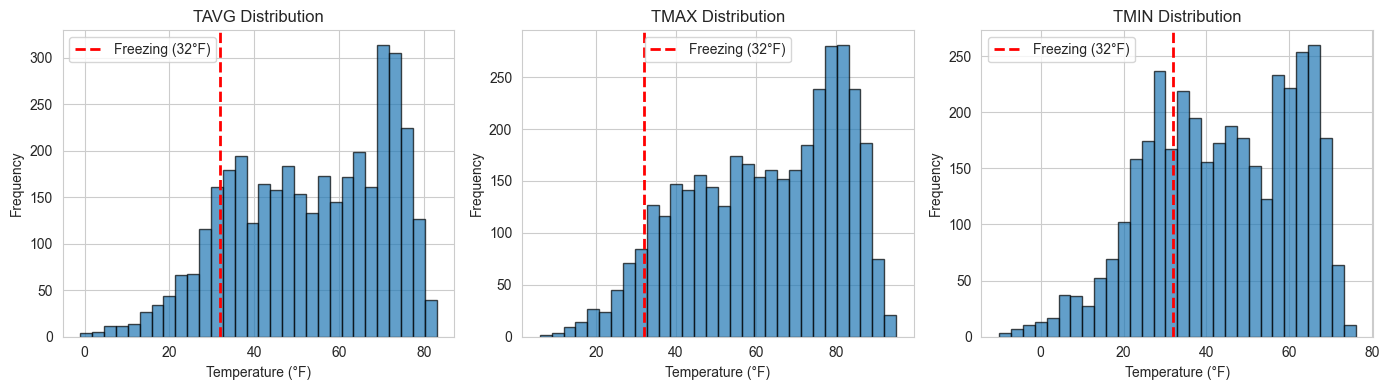

In [31]:
# Temperature distributions
if available_temps:
    fig, axes = plt.subplots(1, len(available_temps), figsize=(14, 4))
    if len(available_temps) == 1:
        axes = [axes]
    
    for i, temp in enumerate(available_temps):
        axes[i].hist(df[temp].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].axvline(32, color='red', linestyle='--', linewidth=2, label='Freezing (32°F)')
        axes[i].set_xlabel('Temperature (°F)')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{temp} Distribution')
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

## 6. Precipitation Analysis

In [32]:
# Precipitation statistics
if 'PRCP' in df.columns:
    print("PRECIPITATION ANALYSIS")
    print("="*70)
    
    prcp = df['PRCP'].fillna(0)
    
    print(f"\nDays with precipitation (>0): {(prcp > 0).sum()} ({(prcp > 0).mean()*100:.1f}%)")
    print(f"Days with significant precip (>0.5''): {(prcp > 0.5).sum()} ({(prcp > 0.5).mean()*100:.1f}%)")
    
    print(f"\nMean: {prcp.mean():.3f} inches")
    print(f"Max: {prcp.max():.3f} inches")
    
    # Compare precipitation vs snowfall
    if 'SNOW' in df.columns:
        both = df[(df['PRCP'] > 0) & (df['SNOW'] > 0)]
        print(f"\nDays with both precipitation AND snow: {len(both)} ({len(both)/len(df)*100:.1f}%)")

PRECIPITATION ANALYSIS

Days with precipitation (>0): 1636 (44.1%)
Days with significant precip (>0.5''): 273 (7.4%)

Mean: 0.116 inches
Max: 3.730 inches

Days with both precipitation AND snow: 338 (9.1%)


## 7. Correlation Analysis

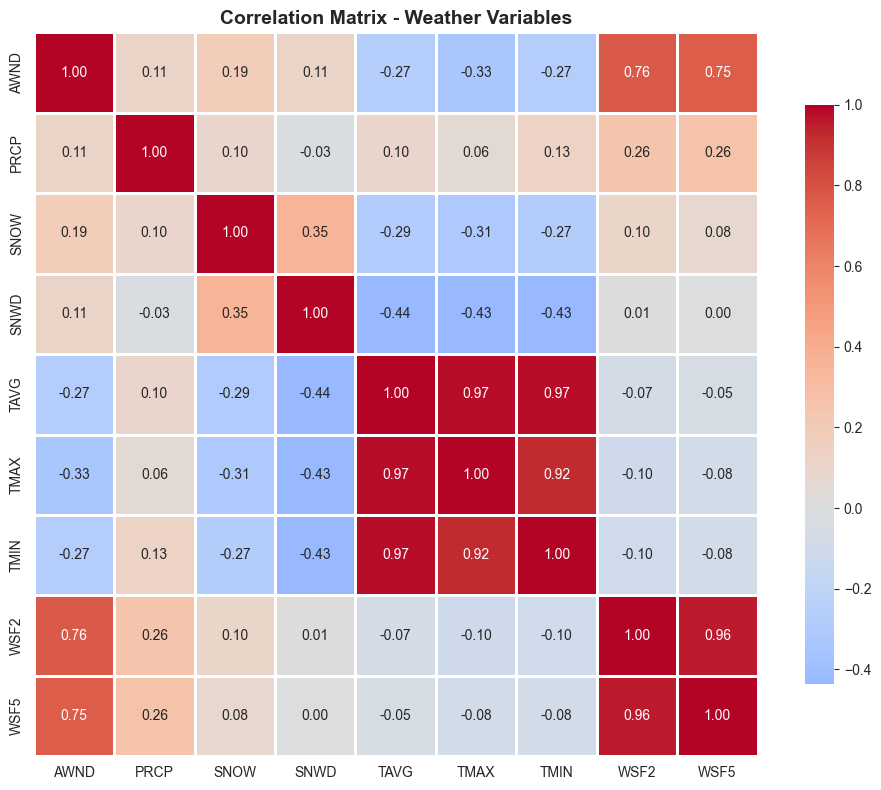


Correlations with SNOW:
SNOW    1.000
SNWD    0.350
AWND    0.185
WSF2    0.103
PRCP    0.101
WSF5    0.084
TMIN   -0.274
TAVG   -0.287
TMAX   -0.313
Name: SNOW, dtype: float64


In [33]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove YEAR, MONTH if present
numeric_cols = [c for c in numeric_cols if c not in ['YEAR', 'MONTH']]

if len(numeric_cols) > 0:
    corr_matrix = df[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix - Weather Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show correlations with SNOW
    if 'SNOW' in corr_matrix.columns:
        print("\nCorrelations with SNOW:")
        snow_corr = corr_matrix['SNOW'].sort_values(ascending=False)
        print(snow_corr)

## 8. Temperature-Snow Relationship

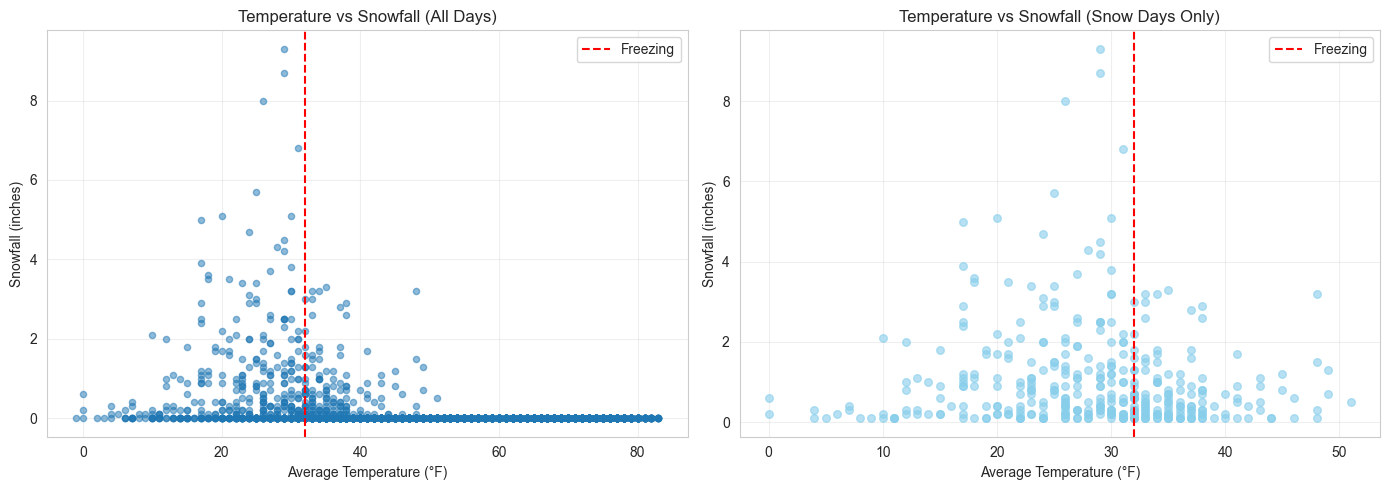


✓ KEY INSIGHT: Most snowfall occurs between 20-32°F
  Temperature is a critical predictor for snowfall


In [34]:
# Scatter plot: Temperature vs Snowfall
if 'TAVG' in df.columns and 'SNOW' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # All days
    axes[0].scatter(df['TAVG'], df['SNOW'], alpha=0.5, s=20)
    axes[0].axvline(32, color='red', linestyle='--', label='Freezing')
    axes[0].set_xlabel('Average Temperature (°F)')
    axes[0].set_ylabel('Snowfall (inches)')
    axes[0].set_title('Temperature vs Snowfall (All Days)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Snow days only
    snow_days = df[df['SNOW'] > 0]
    axes[1].scatter(snow_days['TAVG'], snow_days['SNOW'], alpha=0.6, s=30, color='skyblue')
    axes[1].axvline(32, color='red', linestyle='--', label='Freezing')
    axes[1].set_xlabel('Average Temperature (°F)')
    axes[1].set_ylabel('Snowfall (inches)')
    axes[1].set_title('Temperature vs Snowfall (Snow Days Only)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ KEY INSIGHT: Most snowfall occurs between 20-32°F")
    print("  Temperature is a critical predictor for snowfall")

## 9. Temporal Patterns

YEARLY SNOWFALL SUMMARY
      Total (in)  Daily Avg (in)  Max Event (in)  Days
YEAR                                                  
2015        43.5           0.119             4.3   365
2016        37.4           0.102             4.7   366
2017        37.2           0.102             3.9   365
2018        52.1           0.143             8.7   365
2019        38.6           0.106             4.2   365
2020        42.4           0.116             9.3   366
2021        31.2           0.085             4.5   365
2022        49.2           0.135             8.0   365
2023        13.1           0.036             2.2   365
2024        21.1           0.058             3.3   366
2025        23.0           0.390             2.6    59


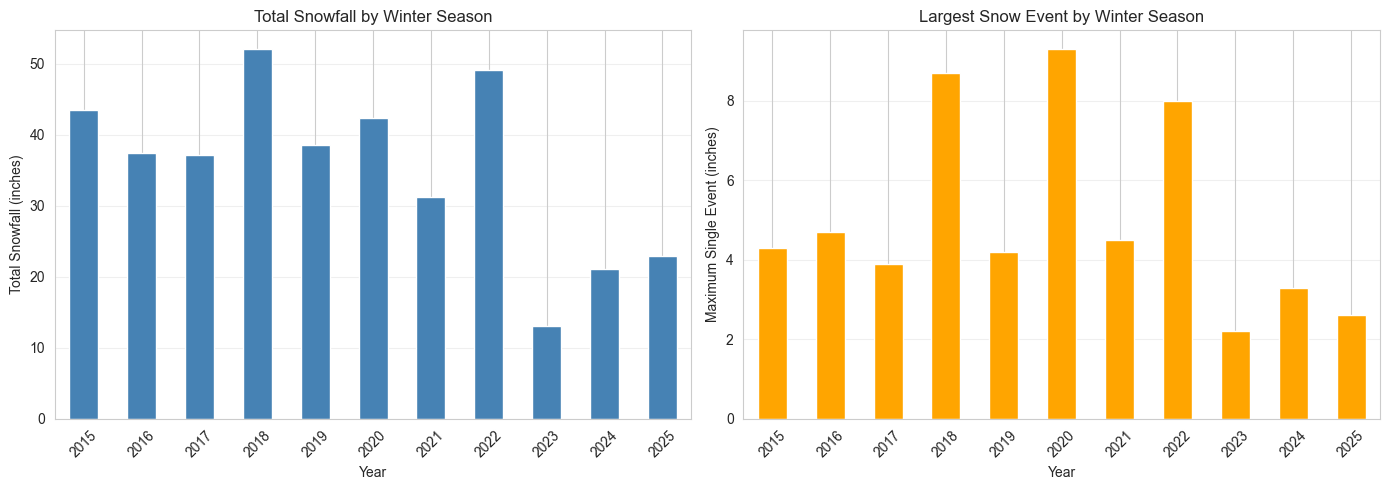

In [35]:
# Snowfall by year
if 'SNOW' in df.columns:
    yearly_snow = df.groupby('YEAR')['SNOW'].agg(['sum', 'mean', 'max', 'count'])
    yearly_snow.columns = ['Total (in)', 'Daily Avg (in)', 'Max Event (in)', 'Days']
    
    print("YEARLY SNOWFALL SUMMARY")
    print("="*70)
    print(yearly_snow)
    
    # Plot yearly totals
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    yearly_snow['Total (in)'].plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Total Snowfall (inches)')
    axes[0].set_title('Total Snowfall by Winter Season')
    axes[0].grid(True, alpha=0.3, axis='y')
    plt.sca(axes[0])
    plt.xticks(rotation=45)
    
    yearly_snow['Max Event (in)'].plot(kind='bar', ax=axes[1], color='orange')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Maximum Single Event (inches)')
    axes[1].set_title('Largest Snow Event by Winter Season')
    axes[1].grid(True, alpha=0.3, axis='y')
    plt.sca(axes[1])
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


MONTHLY SNOWFALL SUMMARY
            Total (in)  Daily Avg (in)  Max Event (in)  Days
MONTH_NAME                                                  
December          63.7           0.205             9.3   310
January          138.0           0.405             5.7   341
February          97.2           0.313             5.1   311


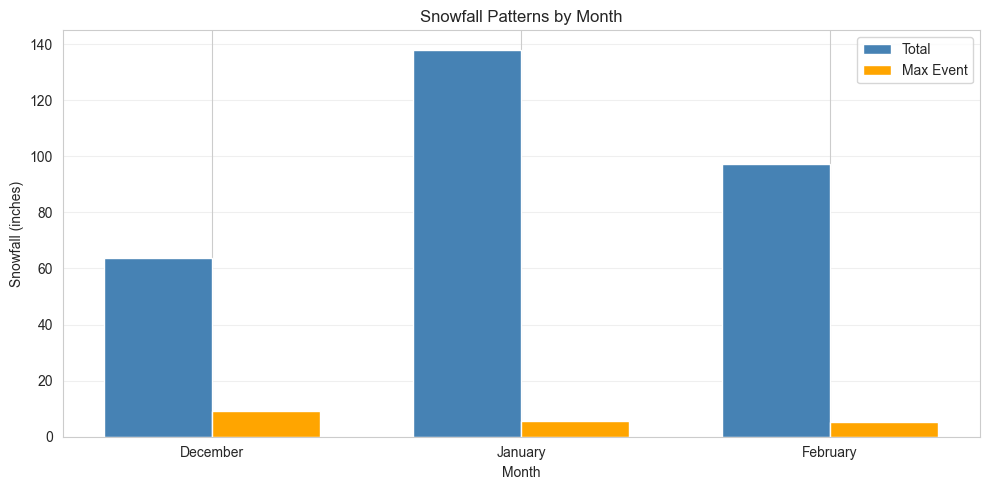


✓ KEY INSIGHT: Snowfall patterns vary by month
  Temporal features (month encoding) will be important


In [36]:
# Snowfall by month
if 'SNOW' in df.columns:
    monthly_snow = df.groupby('MONTH_NAME')['SNOW'].agg(['sum', 'mean', 'max', 'count'])
    monthly_snow.columns = ['Total (in)', 'Daily Avg (in)', 'Max Event (in)', 'Days']
    
    # Reorder months
    month_order = ['December', 'January', 'February']
    monthly_snow = monthly_snow.reindex(month_order)
    
    print("\nMONTHLY SNOWFALL SUMMARY")
    print("="*70)
    print(monthly_snow)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(month_order))
    width = 0.35
    
    ax.bar(x - width/2, monthly_snow['Total (in)'], width, label='Total', color='steelblue')
    ax.bar(x + width/2, monthly_snow['Max Event (in)'], width, label='Max Event', color='orange')
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Snowfall (inches)')
    ax.set_title('Snowfall Patterns by Month')
    ax.set_xticks(x)
    ax.set_xticklabels(month_order)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ KEY INSIGHT: Snowfall patterns vary by month")
    print("  Temporal features (month encoding) will be important")

## 10. Time Series Visualization

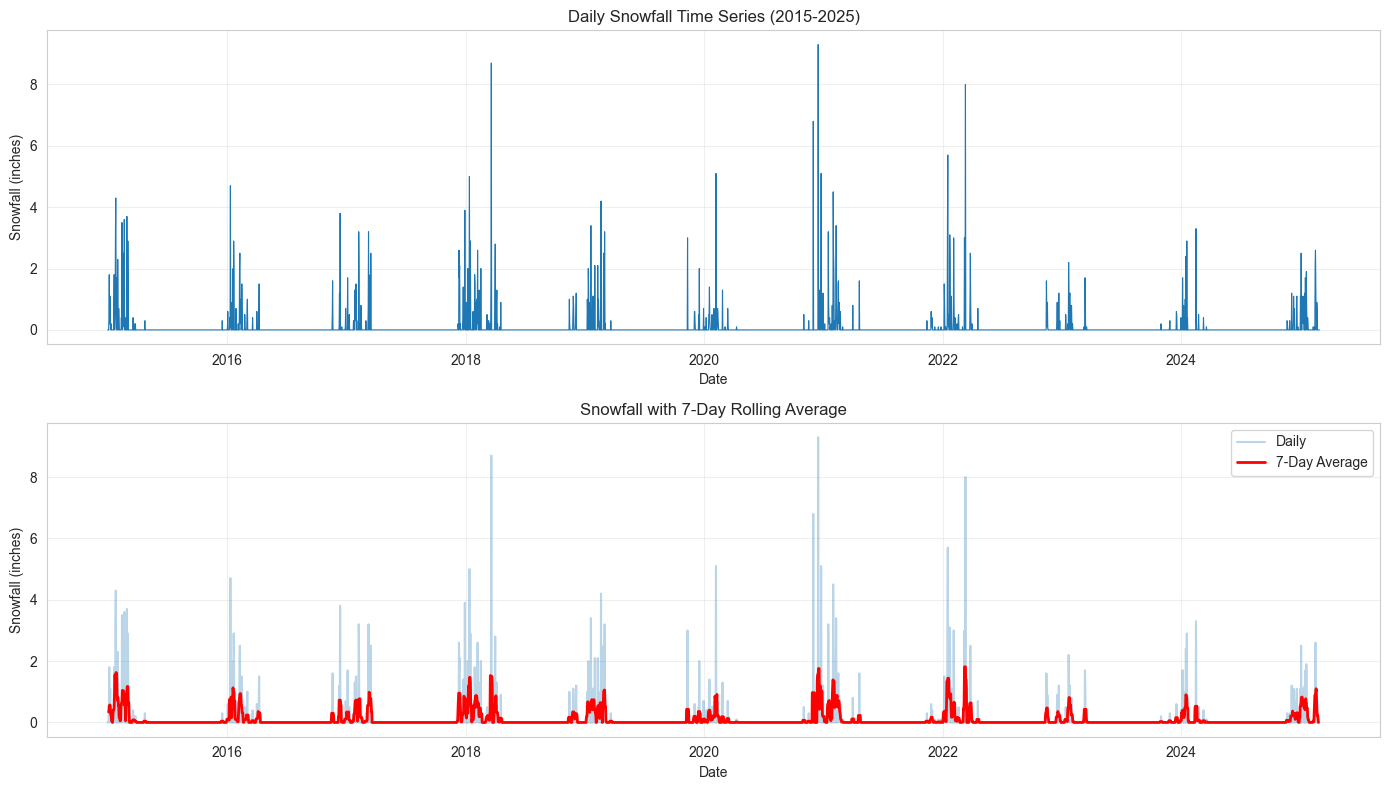


✓ KEY INSIGHT: High variability in daily snowfall
  Rolling averages help identify trends
  LSTM's sequential nature should capture these patterns


In [37]:
# Plot time series
if 'SNOW' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Daily snowfall
    axes[0].plot(df['DATE'], df['SNOW'], linewidth=0.8)
    axes[0].fill_between(df['DATE'], df['SNOW'], alpha=0.3)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Snowfall (inches)')
    axes[0].set_title('Daily Snowfall Time Series (2015-2025)')
    axes[0].grid(True, alpha=0.3)
    
    # 7-day rolling average
    df['SNOW_7D'] = df['SNOW'].rolling(window=7, center=True).mean()
    axes[1].plot(df['DATE'], df['SNOW'], alpha=0.3, label='Daily')
    axes[1].plot(df['DATE'], df['SNOW_7D'], linewidth=2, color='red', label='7-Day Average')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Snowfall (inches)')
    axes[1].set_title('Snowfall with 7-Day Rolling Average')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ KEY INSIGHT: High variability in daily snowfall")
    print("  Rolling averages help identify trends")
    print("  LSTM's sequential nature should capture these patterns")

## 11. Extreme Events Analysis

In [38]:
# Find extreme snow events
if 'SNOW' in df.columns:
    print("EXTREME SNOW EVENTS")
    print("="*70)
    
    # Top 10 snowfall events
    top_events = df.nlargest(10, 'SNOW')[['DATE', 'SNOW', 'TAVG', 'PRCP']]
    top_events.index = range(1, 11)
    
    print("\nTop 10 Snowfall Events:")
    print(top_events)
    
    # Distribution of extreme events
    thresholds = [1.0, 2.0, 3.0, 4.0, 5.0]
    print("\nEvents by Threshold:")
    for thresh in thresholds:
        count = (df['SNOW'] >= thresh).sum()
        pct = count / len(df) * 100
        print(f"  ≥ {thresh}'' : {count} events ({pct:.2f}%)")

EXTREME SNOW EVENTS

Top 10 Snowfall Events:
         DATE  SNOW  TAVG  PRCP
1  2020-12-16   9.3    29  0.66
2  2018-03-21   8.7    29  0.57
3  2022-03-12   8.0    26  0.78
4  2020-12-01   6.8    31  0.52
5  2022-01-17   5.7    25  0.37
6  2020-02-07   5.1    30  0.36
7  2020-12-25   5.1    20  0.26
8  2018-01-13   5.0    17  0.30
9  2016-01-12   4.7    24  0.23
10 2021-01-31   4.5    29  0.39

Events by Threshold:
  ≥ 1.0'' : 136 events (3.66%)
  ≥ 2.0'' : 61 events (1.64%)
  ≥ 3.0'' : 30 events (0.81%)
  ≥ 4.0'' : 12 events (0.32%)
  ≥ 5.0'' : 8 events (0.22%)


## 12. Key Insights Summary

In [39]:
print("="*70)
print("KEY INSIGHTS FOR MODEL DEVELOPMENT")
print("="*70)

insights = [
    "1. ZERO-INFLATED DISTRIBUTION",
    "   - 78% of days have no snow",
    "   - Model must handle both classification and regression",
    "   - Consider weighted loss or two-stage approach",
    "",
    "2. TEMPERATURE CRITICAL",
    "   - Strong relationship between temperature and snowfall",
    "   - Most snow occurs between 20-32°F",
    "   - Wind chill feature will be important",
    "",
    "3. TEMPORAL PATTERNS",
    "   - Significant year-to-year variation",
    "   - Monthly differences (Jan typically snowiest)",
    "   - Sequential patterns visible in time series",
    "   - LSTM well-suited for capturing these dependencies",
    "",
    "4. HIGH VARIABILITY",
    "   - Daily snowfall highly variable (std: ~0.7'')",
    "   - Extreme events rare but important (>3'': 2%)",
    "   - Rolling features will help smooth noise",
    "",
    "5. FEATURE ENGINEERING NEEDS",
    "   - Temperature features (including wind chill)",
    "   - Temporal encoding (month, day of year, cyclical)",
    "   - Rolling averages (3-day, 7-day)",
    "   - Lag features (previous days)",
    "   - Freezing indicators (binary features)",
    "",
    "6. EVALUATION CONSIDERATIONS",
    "   - RMSE/MAE for continuous predictions",
    "   - Binary metrics for snow/no-snow",
    "   - Focus on recall for extreme events (safety)",
    "   - Temporal train/test split essential",
]

for insight in insights:
    print(insight)

print("="*70)

KEY INSIGHTS FOR MODEL DEVELOPMENT
1. ZERO-INFLATED DISTRIBUTION
   - 78% of days have no snow
   - Model must handle both classification and regression
   - Consider weighted loss or two-stage approach

2. TEMPERATURE CRITICAL
   - Strong relationship between temperature and snowfall
   - Most snow occurs between 20-32°F
   - Wind chill feature will be important

3. TEMPORAL PATTERNS
   - Significant year-to-year variation
   - Monthly differences (Jan typically snowiest)
   - Sequential patterns visible in time series
   - LSTM well-suited for capturing these dependencies

4. HIGH VARIABILITY
   - Daily snowfall highly variable (std: ~0.7'')
   - Extreme events rare but important (>3'': 2%)
   - Rolling features will help smooth noise

5. FEATURE ENGINEERING NEEDS
   - Temperature features (including wind chill)
   - Temporal encoding (month, day of year, cyclical)
   - Rolling averages (3-day, 7-day)
   - Lag features (previous days)
   - Freezing indicators (binary features)

6. EV

## 13. Export Summary Statistics

In [41]:
# Create summary report
summary_stats = {
    'Total Days': len(df),
    'Date Range': f"{df['DATE'].min()} to {df['DATE'].max()}",
    'Years': df['YEAR'].nunique(),
    'Snow Days (>0)': (df['SNOW'] > 0).sum() if 'SNOW' in df.columns else 'N/A',
    'Snow Days (%)': f"{(df['SNOW'] > 0).mean()*100:.1f}%" if 'SNOW' in df.columns else 'N/A',
    'Mean Snowfall': f"{df['SNOW'].mean():.3f} in" if 'SNOW' in df.columns else 'N/A',
    'Max Snowfall': f"{df['SNOW'].max():.3f} in" if 'SNOW' in df.columns else 'N/A',
    'Mean Temperature': f"{df['TAVG'].mean():.1f}°F" if 'TAVG' in df.columns else 'N/A',
    'Min Temperature': f"{df['TAVG'].min():.1f}°F" if 'TAVG' in df.columns else 'N/A',
    'Max Temperature': f"{df['TAVG'].max():.1f}°F" if 'TAVG' in df.columns else 'N/A',
}

print("\nDATA SUMMARY")
print("="*70)
for key, value in summary_stats.items():
    print(f"{key:.<40} {value}")

print("\n✓ EDA Complete!")


DATA SUMMARY
Total Days.............................. 3712
Date Range.............................. 2015-01-01 00:00:00 to 2025-02-28 00:00:00
Years................................... 11
Snow Days (>0).......................... 365
Snow Days (%)........................... 9.8%
Mean Snowfall........................... 0.105 in
Max Snowfall............................ 9.300 in
Mean Temperature........................ 53.1°F
Min Temperature......................... -1.0°F
Max Temperature......................... 83.0°F

✓ EDA Complete!
